Neste notebook, vamos analisar dados macroeconómicos para prever o preço de ativos financeiros utilizando Regressão Linear Múltipla ($y = Xw + b$).

In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.database import carregar_dados

# Carrega os dados do PostgreSQL
df = carregar_dados()
df.head()

,preco_ativo,taxa_inflacao,volume_negociado,taxa_juros
0,125.58,0.0387,4008,0.0806
1,134.14,0.0675,4279,0.0870
2,124.32,0.0566,2424,0.1196
3,128.89,0.0499,4456,0.0822
4,116.09,0.0278,3081,0.0719


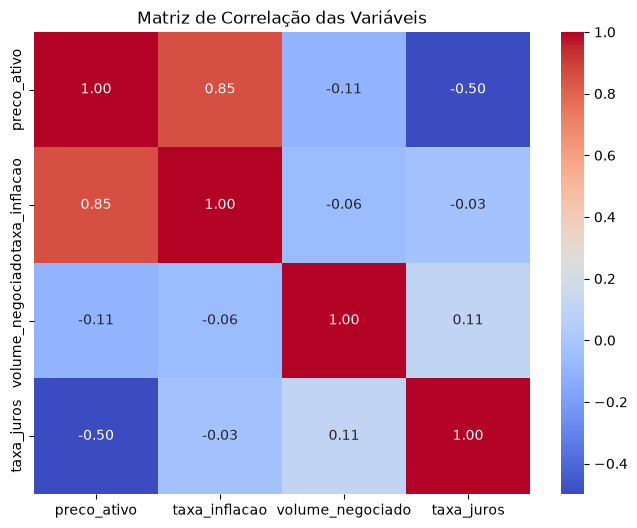

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Variáveis")
plt.show()

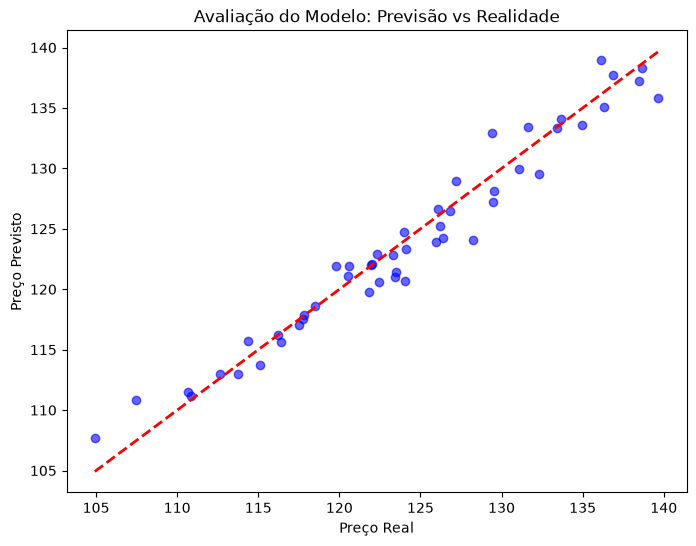

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Preparação
X = df[['taxa_inflacao', 'taxa_juros']] # Remove o volume, pois a correlação mostrou ser baixa
y = df['preco_ativo']
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Treino e Previsão
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)

# Gráfico de Previsões vs Realidade
plt.figure(figsize=(8, 6))
plt.scatter(y_teste, previsoes, color='blue', alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2) # Linha de acerto 100%
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.title("Avaliação do Modelo: Previsão vs Realidade")
plt.show()